In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [77]:
df = pd.read_csv('diabetes_noise 5.csv')

In [78]:
def validate_integer_values(df, column_name):
    invalid_indices = []
    for idx, value in enumerate(df[column_name]):
        try:
            int(value)
        except (ValueError, TypeError):
            invalid_indices.append(idx + 2)

    return invalid_indices

In [79]:
def check_missing_values(df, column_name):
    missing_indices = []
    for idx, value in enumerate(df[column_name]):
        if pd.isnull(value):
            missing_indices.append(idx + 2)

    return missing_indices

In [80]:
invalid_age_indices = validate_integer_values(df, 'Age')
if invalid_age_indices:
    print(f"Invalid age values found at indices: {invalid_age_indices}")
else:
    print("All age values are valid integers!")

Invalid age values found at indices: [20, 30]


In [81]:
df_missing = pd.read_csv('diabetes_NaN_age 3.csv')
missing_age_indices = check_missing_values(df_missing, 'Age')
if missing_age_indices:
    print(f"Missing age values found at indices: {missing_age_indices}")
else:
    print("No missing age values found!")

Missing age values found at indices: [2, 4]


In [82]:
# Method 1: fill only the missing Age values using pandas
df_method1 = df_missing.copy()
missing_age_mask = df_method1['Age'].isna()
age_mean = df_method1['Age'].mean()
df_method1.loc[missing_age_mask, 'Age'] = age_mean
print(df_method1.loc[missing_age_mask, 'Age'])

0    33.194517
2    33.194517
Name: Age, dtype: float64


In [83]:
# Method 2: transform the entire Age column with SimpleImputer
df_method2 = df_missing.copy()
imputer_mean = SimpleImputer(strategy='mean', missing_values=np.nan)
df_method2['Age'] = imputer_mean.fit_transform(df_method2[['Age']]).ravel()
print(df_method2.loc[[0, 2], 'Age'])

0    33.194517
2    33.194517
Name: Age, dtype: float64


In [84]:
# Method 3: assign only the imputed values at the missing rows
df_method3 = df_missing.copy()
missing_age_mask = df_method3['Age'].isna()
imputer_mean = SimpleImputer(strategy='mean', missing_values=np.nan)
imputed_ages = imputer_mean.fit_transform(df_method3[['Age']]).ravel()
df_method3.loc[missing_age_mask, 'Age'] = imputed_ages[missing_age_mask.to_numpy()]
print(df_method3.loc[missing_age_mask, 'Age'])

0    33.194517
2    33.194517
Name: Age, dtype: float64


In [85]:
data = pd.read_csv('CardioGoodFitness 4.csv')

In [86]:
df_cardio = pd.DataFrame(data)

In [87]:
plot_categories = ['Single', 'Partnered']

mean_income_single = df_cardio.loc[df_cardio['MaritalStatus'] == 'Single', 'Income'].mean()
mean_income_partnered = df_cardio.loc[df_cardio['MaritalStatus'] == 'Partnered', 'Income'].mean()
truncate_mean_single = round(mean_income_single,2)
truncate_mean_partnered = round(mean_income_partnered,2)

values = [truncate_mean_single, truncate_mean_partnered]

In [88]:
print(values)

[np.float64(51016.28), np.float64(55870.74)]


In [89]:
observed_categories = df_cardio['MaritalStatus'].unique()

In [90]:
print(observed_categories)

<StringArray>
['Single', 'Partnered', 'Married', 'Singl', 'Partner']
Length: 5, dtype: str


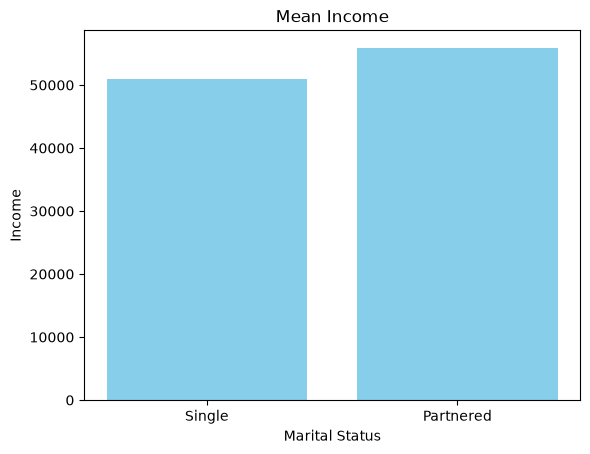

In [91]:
plt.bar(plot_categories, values, color='skyblue')
plt.xlabel('Marital Status')
plt.ylabel('Income')
plt.title('Mean Income')

plt.show()

In [92]:
data = pd.read_csv('diabetes 7.csv')
pf = pd.DataFrame(data)

In [93]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6.0    148.0             72             35        0  33.6   
1            1.0     85.0             66             29        0  26.6   
2            8.0    183.0             64              0        0  23.3   
3            1.0     89.0             66             23       94  28.1   
4            0.0    137.0             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763         10.0    101.0             76             48      180  32.9   
764          2.0    122.0             70             27        0  36.8   
765          5.0    121.0             72             23      112  26.2   
766          1.0    126.0             60              0        0  30.1   
767          1.0     93.0             70             31        0  30.4   

     DiabetesPedigreeFunction Age  Outcome  
0                       0.627  40      1.0  
1                    

In [94]:
from sklearn.preprocessing import StandardScaler

In [95]:
# Using StandardScaler: Scale a specific numeric column
column_to_scale = df[['DiabetesPedigreeFunction']]
scaler = StandardScaler()
scaled_column = scaler.fit_transform(column_to_scale)
df['Scaled_DPF'] = scaled_column
print(df[['DiabetesPedigreeFunction','Scaled_DPF']])

     DiabetesPedigreeFunction  Scaled_DPF
0                       0.627    0.468492
1                       0.351   -0.365061
2                       0.672    0.604397
3                       0.167   -0.920763
4                       2.288    5.484909
..                        ...         ...
763                     0.171   -0.908682
764                     0.340   -0.398282
765                     0.245   -0.685193
766                     0.349   -0.371101
767                     0.315   -0.473785

[768 rows x 2 columns]


In [96]:
# Using StandardScaler: Scale all numeric column
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.643727  0.855142       0.149641       0.907270 -0.692891  0.201416   
1      -0.841048 -1.126243      -0.160546       0.530902 -0.692891 -0.686305   
2       1.237637  1.955911      -0.263941      -1.288212 -0.692891 -1.104802   
3      -0.841048 -1.000441      -0.160546       0.154533  0.123302 -0.496079   
4      -1.138004  0.509186      -1.504687       0.907270  0.765836  1.406179   
..           ...       ...            ...            ...       ...       ...   
763     1.831547 -0.623034       0.356432       1.722735  0.870031  0.112644   
764    -0.544093  0.037427       0.046245       0.405445 -0.692891  0.607231   
765     0.346772  0.005977       0.149641       0.154533  0.279594 -0.737032   
766    -0.841048  0.163230      -0.470732      -1.288212 -0.692891 -0.242445   
767    -0.841048 -0.874639       0.046245       0.656358 -0.692891 -0.204399   

     DiabetesPedigreeFunction Age   Out

In [97]:
from sklearn.preprocessing import MinMaxScaler

In [99]:
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(df)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0       0.352941  0.743719       0.590164       0.353535  0.000000  0.500745   
1       0.058824  0.427136       0.540984       0.292929  0.000000  0.396423   
2       0.470588  0.919598       0.524590       0.000000  0.000000  0.347243   
3       0.058824  0.447236       0.540984       0.232323  0.111111  0.418778   
4       0.000000  0.688442       0.327869       0.353535  0.198582  0.642325   
..           ...       ...            ...            ...       ...       ...   
763     0.588235  0.507538       0.622951       0.484848  0.212766  0.490313   
764     0.117647  0.613065       0.573770       0.272727  0.000000  0.548435   
765     0.294118  0.608040       0.590164       0.232323  0.132388  0.390462   
766     0.058824  0.633166       0.491803       0.000000  0.000000  0.448584   
767     0.058824  0.467337       0.573770       0.313131  0.000000  0.453055   

     DiabetesPedigreeFunction Age  Outc